In [2]:
import pandas as pd

df = pd.read_csv("housing_trimmed_variables.csv")
df.head()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
2,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1
3,52.0,1274.0,558.0,5.6431,341300.0,17.06,0,0,0,1
4,52.0,1627.0,565.0,3.8462,342200.0,17.06,0,0,0,1


In [ ]:
fdfdf

In [3]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.005) 
df = pd.read_csv("housing_trimmed_variables.csv")

# REMEMBER! Isolation Forest is a machine learning algorithm
# => ALL VARIABLES HAVE TO BE NUMERIC AT THIS POINT

# My dataset has all data numeric.

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 18230
Outliers: 92


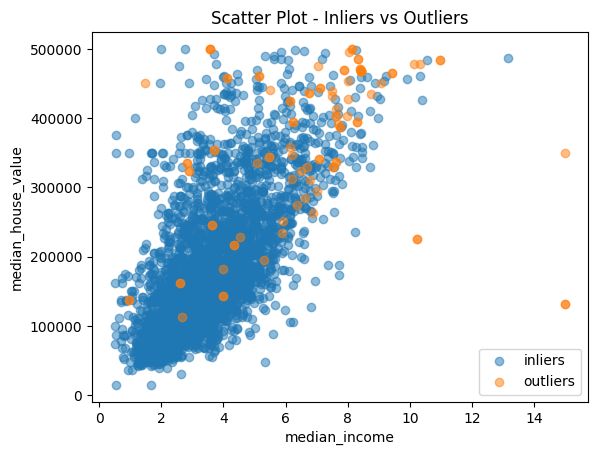

In [5]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "median_income"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(3000)
outliers_sample = outliers.sample(100, replace=True)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [6]:
outliers

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
88,10.0,105.0,125.0,0.9722,137500.0,13.42,0,0,0,1
102,34.0,5871.0,2689.0,2.8406,335700.0,14.54,0,0,0,1
497,14.0,7355.0,3100.0,4.0018,143800.0,12.74,0,0,0,1
548,21.0,7031.0,2930.0,4.5213,228400.0,16.54,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
16691,13.0,5451.0,2957.0,2.6098,162500.0,36.39,0,0,0,1
16746,13.0,7367.0,3193.0,5.3102,195000.0,58.80,0,0,0,1
16748,2.0,6718.0,2012.0,6.8872,305200.0,65.52,0,1,0,0
16893,8.0,5875.0,2808.0,3.6392,246300.0,44.65,0,0,0,1


###  Elliptic Envelope

In [7]:
from sklearn.covariance import EllipticEnvelope

# contamination, same thing as in isolation
ee = EllipticEnvelope(contamination=0.005)
df = pd.read_csv("housing_trimmed_variables.csv")


y_pred = ee.fit_predict(df)
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

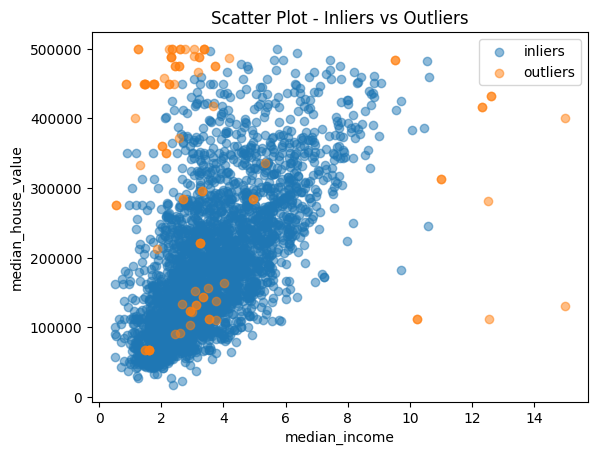

In [9]:
import matplotlib.pyplot as plt

variable = "median_income"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(3000)
outliers_sample = outliers.sample(100, replace=True)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [10]:
outliers

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
451,42.0,1756.0,2184.0,2.5562,371400.0,18.25,0,0,0,1
452,52.0,1204.0,2016.0,0.9490,350000.0,18.25,0,0,0,1
480,48.0,2153.0,1656.0,3.0417,489600.0,17.63,0,0,0,1
1142,9.0,7450.0,2233.0,2.6528,133000.0,155.08,0,1,0,0
1471,8.0,452.0,140.0,12.5915,432400.0,44.07,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
16329,26.0,50.0,17.0,15.0001,400000.0,82.38,1,0,0,0
16497,22.0,7281.0,1849.0,5.3276,335500.0,104.57,0,0,0,0
17142,9.0,5409.0,594.0,3.3125,295400.0,139.01,0,0,0,0
17308,39.0,45.0,22.0,1.7679,450000.0,132.89,0,1,0,0
